# Getting started
`FASTAR` offers a large number of ways to interact with the synthesis of evolutionary stellar population models. This notebook offers a quick guide through the most basic functionalities

In [2]:
from matplotlib import pyplot as plt

## Generating a standard SSP model (for spectroscopy)
If you are interested in analyzing of spectrocopic data, these are most likely your models.

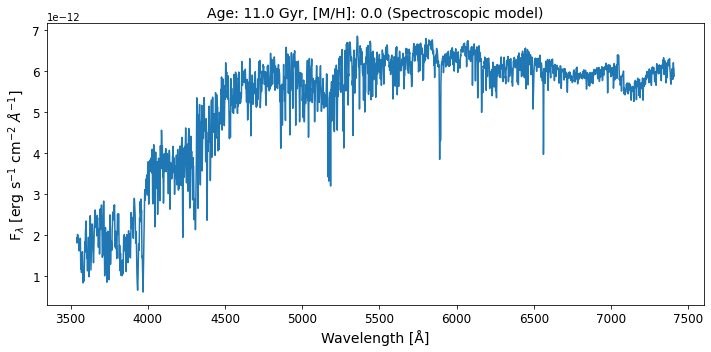

In [ ]:
# Let's load the SSP synthesizer and an IMF
from fastar import IntegratedSSPSynthesizer
from fastar.imf import kroupa

# Now we can initialize the synthesizer
ssp = IntegratedSSPSynthesizer(imf_function=kroupa)

# Now you can generate SSP models for any age and metallicity
age = 11.0
met = 0.0

# Synthesize SSP
spec = ssp.synthesize(age=age, met=met)
wavelength = ssp.wave

# Let's see how it looks
figsize = (10, 5)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wavelength, spec)
ax.set_xlabel('Wavelength [Å]', fontsize=14)
ax.set_ylabel('F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=14)
ax.set_title(f'Age: {age} Gyr, [M/H]: {met}', fontsize=14)
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()

## Generating a standard SSP model (for photometric analysis)
If you have photometric data beyond the spectroscopic coverage of `FASTAR`, don't worry, you can use instead our photometric models. They have a coarse wavelength sampling (Δλ=4Å) but cover a wider wavelength range so you can convolve them with your favorite set of photometric filters


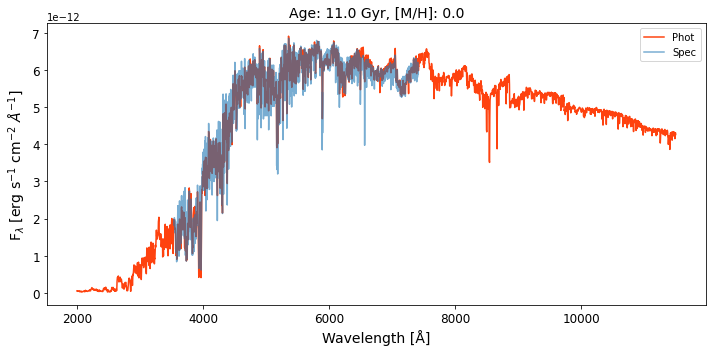

In [13]:
# The calling sequence is the same, but specifying that you want the photometric predictions while loading the synthesizer
ssp_phot = IntegratedSSPSynthesizer(model_label='phot', imf_function=kroupa)

# Using the same age and metallicity as before
age = 11.0
met = 0.0

# Synthesize SSP
sed = ssp_phot.synthesize(age=age, met=met)
wavelength_phot = ssp_phot.wave

# Let's see how it looks
figsize = (10, 5)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wavelength_phot, sed, color='xkcd:orangered', label='Phot')
ax.plot(wavelength, spec, alpha=0.6, label='Spec')
ax.legend()
ax.set_xlabel('Wavelength [Å]', fontsize=14)
ax.set_ylabel('F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=14)
ax.set_title(f'Age: {age} Gyr, [M/H]: {met}', fontsize=14)
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()

## Generating a semi-resolved SSP model
A unique feature of `FASTAR` is the possibility of generating SSP models for semi-resolved stellar populations, i.e., without assuming an infinite number of stars contributing to the spectrum. Synthesizing these models is also straight-forward, with only an additional free parameter determining the number of stars you want in your model.

In [15]:
# The synthesis is rather similar although we also need to import a JAX key generator for the IMF sampling
import jax
from fastar import SemiresolvedSSPSynthesizer

# Now we can load the semi-resolved synthesizer
semi = SemiresolvedSSPSynthesizer(imf_function=kroupa)

# Generate the key
key = jax.random.PRNGKey(0)

# And then simply synthesize a semi-resolved model
age = 11.0
met = 0.0
nstars = 1000

# Synthesize SSP
semi_model, semi_stellar_mass = semi.synthesize(
    age=age, met=met, num_stars=int(nstars), key=key
)

A single semi-resolved model doesn't probably say may because they are stochastic and thus predictions are not unique even with the same age, metallicity, IMF and number of stars. Let's do a bunch of them instead

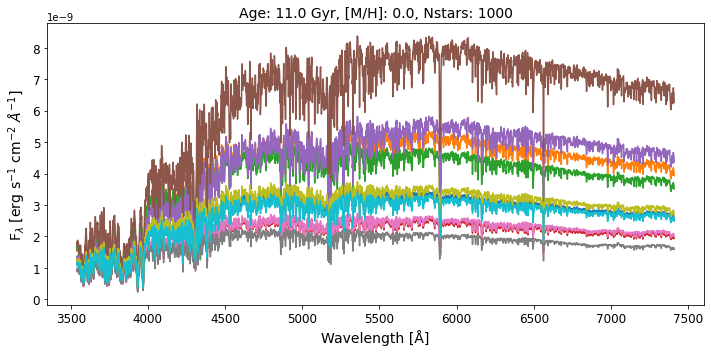

In [20]:
# We first define the number of models and split the random key
nmodels = 10
keys = jax.random.split(key, nmodels)

figsize = (10, 5)
fig, ax = plt.subplots(figsize=(10, 5))

for i in range(nmodels):
    semi_model, _ = semi.synthesize(
        age=age, met=met, num_stars=int(nstars), key=keys[i]
    )
    plt.plot(wavelength, semi_model)
ax.set_xlabel('Wavelength [Å]', fontsize=14)
ax.set_ylabel('F$_\lambda$ [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]', fontsize=14)
ax.set_title(f'Age: {age} Gyr, [M/H]: {met}, Nstars: {nstars}', fontsize=14)
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()